In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error
import yfinance as yf

In [1]:
df = yf.download("AAPL", start="2020-01-01", end="2024-12-31")
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
df.tail()

NameError: name 'yf' is not defined

In [3]:
df['Return'] = df['Close'].pct_change()
df['SMA_5'] = df['Close'].rolling(5).mean()
df['SMA_10'] = df['Close'].rolling(10).mean()
df['Lag_1'] = df['Close'].shift(1)
df['Target'] = df['Close'].shift(-1)  # Predicting next-day price

In [4]:
df.dropna(inplace=True)

In [5]:
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Return', 'SMA_5', 'SMA_10', 'Lag_1']
X = df[features]
y = df['Target']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [7]:
model = XGBRegressor(objective='reg:squarederror', n_estimators=100)
model.fit(X_train, y_train)

preds = model.predict(X_test)
rmse = root_mean_squared_error(y_test, preds)
print(f"RMSE: {rmse:.4f}")

RMSE: 26.1346


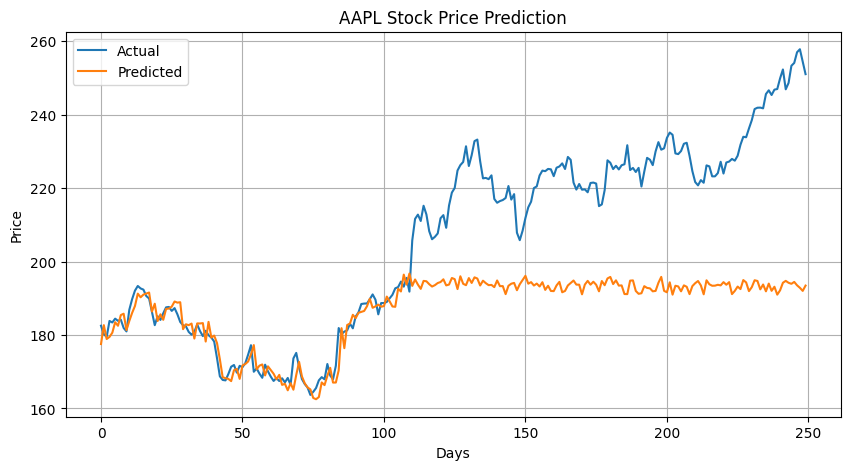

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label="Actual")
plt.plot(preds, label="Predicted")
plt.title("AAPL Stock Price Prediction")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

In [9]:
accuracy = ( (preds[1:] > preds[:-1]) == (y_test.values[1:] > y_test.values[:-1]) ).mean()
print(f"Directional Accuracy: {accuracy:.2%}")

Directional Accuracy: 52.21%


https://medium.com/@bps1418.usa/training-xgboost-on-stock-price-data-a-practical-guide-to-predict-market-movements-d26f3ad64c14